
# EEGNet (Protocol-Based)

Intra-subject and cross-subject MEG decoding with EEGNet, run under the
shared assignment protocol in `protocol_utils.py`.

All preprocessing, splitting, and metrics go through the shared helper module. Only the model architecture is specific to this notebook.

Architecture: EEGNet (Lawhern et al. 2018), adapted for 248-sensor MEG.
Reference: https://github.com/vlawhern/arl-eegmodels/blob/master/EEGModels.py 


In [18]:
# Imports

import sys
sys.path.append("..")

import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import keras
from keras import layers, models
from keras.constraints import max_norm

from protocol_utils import (
    CLASS_NAMES,
    DatasetPaths,
    PreprocessConfig,
    list_files,
    prepare_protocol_data,
    split_files_train_val,
    group_files_by_subject,
)

# Determinism (best effort under Keras)
keras.utils.set_random_seed(0)

In [19]:
# Configuration

paths = DatasetPaths(data_root="../data")
BASE_PREPROCESS = PreprocessConfig(
    downsample_factor=4,
    window_size=512,
    stride=256,
)

# Constants derived from the protocol
N_SENSORS = 248
N_CLASSES = 4
N_SAMPLES = BASE_PREPROCESS.window_size                  # 512
EFFECTIVE_SR = BASE_PREPROCESS.effective_sample_rate_hz  # 2034 / 4 = 508.5 Hz

# Training hyperparameters
BATCH_SIZE = 16
MAX_TUNE_EPOCHS = 40        # max epochs per LOSO/val fold during tuning
TUNE_PATIENCE = 8           # early-stop patience on file-level metric
FINAL_EPOCH_CAP = 40        # absolute upper bound on final retrain epochs


print(f"Effective sample rate: {EFFECTIVE_SR:.1f} Hz")
print(f"Window: {N_SAMPLES} samples ({N_SAMPLES / EFFECTIVE_SR:.2f} s)")

Effective sample rate: 508.5 Hz
Window: 512 samples (1.01 s)


## Candidate dataclass + tuning grid

 Each candidate fully specifies a hyperparameter setup. The grid varies the
 regularisation/capacity axes most likely to matter for a small MEG dataset.


In [20]:
@dataclass(frozen=True)
class Candidate:
    name: str
    preprocess: PreprocessConfig = BASE_PREPROCESS
    lr: float = 5e-4
    F1: int = 8
    D: int = 2
    kernel_1: tuple = (1, 128)
    kernel_3: tuple = (1, 32)
    pool_1: tuple = (1, 8)
    pool_2: tuple = (1, 16)
    dropout: float = 0.5
    norm_rate: float = 0.25


TUNING_GRID: list[Candidate] = [
    Candidate(
        name="baseline_paper_scaled",
        # Kernels scaled to ~508 Hz, paper-faithful pooling ratios.
        kernel_1=(1, 128), kernel_3=(1, 32),
        pool_1=(1, 8), pool_2=(1, 16),
        dropout=0.5, F1=8, D=2, lr=5e-4,
    ),
    Candidate(
        name="stronger_regularisation",
        # Higher dropout in case the baseline overfits the small dataset.
        kernel_1=(1, 128), kernel_3=(1, 32),
        pool_1=(1, 8), pool_2=(1, 16),
        dropout=0.6, F1=8, D=2, lr=5e-4,
    ),
    Candidate(
        name="shorter_kernel",
        # Half-size temporal kernel (~0.13 s coverage) — fewer params, faster.
        kernel_1=(1, 64), kernel_3=(1, 16),
        pool_1=(1, 8), pool_2=(1, 16),
        dropout=0.5, F1=8, D=2, lr=5e-4,
    ),
    Candidate(
        name="lower_capacity",
        # Halved temporal filters: smaller model, less overfitting risk.
        kernel_1=(1, 128), kernel_3=(1, 32),
        pool_1=(1, 8), pool_2=(1, 16),
        dropout=0.5, F1=4, D=2, lr=5e-4,
    ),
]

for c in TUNING_GRID:
    print(c)

Candidate(name='baseline_paper_scaled', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), lr=0.0005, F1=8, D=2, kernel_1=(1, 128), kernel_3=(1, 32), pool_1=(1, 8), pool_2=(1, 16), dropout=0.5, norm_rate=0.25)
Candidate(name='stronger_regularisation', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), lr=0.0005, F1=8, D=2, kernel_1=(1, 128), kernel_3=(1, 32), pool_1=(1, 8), pool_2=(1, 16), dropout=0.6, norm_rate=0.25)
Candidate(name='shorter_kernel', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), lr=0.0005, F1=8, D=2, kernel_1=(1, 64), kernel_3=(1, 16), pool_1=(1, 8), pool_2=(1, 16), dropout=0.5, norm_rate=0.25)
Candidate(name='lower_capacity', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), lr=0.0005, F1=4, D=2, ke

## EEGNet model
Builds a Keras EEGNet from a `Candidate`. Input shape matches the protocol:
 `(n_windows, n_sensors, window_size)`, with a `Reshape` layer adding the trailing channel dim expected by `Conv2D`.


In [21]:
def build_eegnet(candidate: Candidate,
                 n_channels: int = N_SENSORS,
                 n_samples: int = N_SAMPLES,
                 n_classes: int = N_CLASSES) -> keras.Model:
    F1 = candidate.F1
    D = candidate.D
    F2 = F1 * D

    inp = layers.Input(shape=(n_channels, n_samples))
    x = layers.Reshape((n_channels, n_samples, 1))(inp)

    # Block 1: temporal + spatial conv
    x = layers.Conv2D(F1, candidate.kernel_1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.DepthwiseConv2D(
        (n_channels, 1), depth_multiplier=D, use_bias=False,
        depthwise_constraint=max_norm(1.0),
    )(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D(pool_size=candidate.pool_1)(x)
    x = layers.SpatialDropout2D(candidate.dropout)(x)

    # Block 2: separable conv
    x = layers.SeparableConv2D(F2, candidate.kernel_3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D(pool_size=candidate.pool_2)(x)
    x = layers.SpatialDropout2D(candidate.dropout)(x)

    # Classifier head
    x = layers.Flatten()(x)
    out = layers.Dense(n_classes, kernel_constraint=max_norm(candidate.norm_rate))(x)
    return models.Model(inputs=inp, outputs=out, name=f"EEGNet_{candidate.name}")


def compile_model(model: keras.Model, candidate: Candidate) -> keras.Model:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=candidate.lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return model


# Quick parameter-count check
for c in TUNING_GRID:
    m = build_eegnet(c)
    print(f"{c.name:<30s}  params: {m.count_params():,}")
    del m

baseline_paper_scaled           params: 6,180
stronger_regularisation         params: 6,180
shorter_kernel                  params: 5,412
lower_capacity                  params: 3,028


## Training helpers

 - `make_predict_logits(model)` implements the protocol contract.
 - `fit_with_file_acc_tracking` trains one epoch at a time, evaluates
   file-level accuracy after each epoch (via the protocol's `evaluate`), and
   early-stops on the protocol's primary metric.
 - `train_final` retrains on all training data with no held-out validation.


In [22]:
def make_predict_logits(model: keras.Model):
    def predict_logits(windows: np.ndarray) -> np.ndarray:
        return model.predict(windows, verbose=0)
    return predict_logits


def fit_with_file_acc_tracking(model: keras.Model,
                                data,
                                max_epochs: int = MAX_TUNE_EPOCHS,
                                patience: int = TUNE_PATIENCE,
                                verbose: bool = False) -> tuple[dict, list[dict]]:
    """Train one epoch at a time, scoring with the protocol's file_acc.

    Tracks the best (file_acc, window_acc) on the data's test_files (i.e. the
    held-out validation files) and restores best weights at the end.
    """
    best = {"epoch": 0, "file_acc": -1.0, "window_acc": -1.0}
    best_weights = None
    bad = 0
    history: list[dict] = []
    predict = make_predict_logits(model)

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        h = model.fit(
            data.X_train, data.y_train,
            epochs=1, batch_size=BATCH_SIZE, verbose=0,
        )
        train_loss = float(h.history["loss"][-1])
        train_acc = float(h.history["accuracy"][-1])

        # Evaluate at file level on the held-out files
        m = data.evaluate(predict)
        window_acc = float(m["window_acc"])
        file_acc = float(m["file_acc"])
        history.append({
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
            "window_acc": window_acc, "file_acc": file_acc,
        })

        improved = (
            file_acc > best["file_acc"] + 1e-4
            or (abs(file_acc - best["file_acc"]) <= 1e-4
                and window_acc > best["window_acc"] + 1e-4)
        )
        if improved:
            best = {"epoch": epoch, "file_acc": file_acc, "window_acc": window_acc}
            best_weights = [w.copy() for w in model.get_weights()]
            bad = 0
        else:
            bad += 1

        if verbose:
            print(f"  ep {epoch:02d}  train {train_loss:.3f}/{train_acc:.3f}  "
                  f"val win/file {window_acc:.3f}/{file_acc:.3f}  "
                  f"({time.time()-t0:.1f}s)")

        if bad >= patience:
            break

    if best_weights is not None:
        model.set_weights(best_weights)
    return best, history


def train_final(candidate: Candidate, epochs: int, train_paths) -> tuple[keras.Model, Any]:
    """Train final model on ALL training files (no validation split)."""
    data = prepare_protocol_data(
        train_paths, val_frac=0, config=candidate.preprocess,
    )
    model = compile_model(build_eegnet(candidate), candidate)
    print(f"Training final model: {candidate.name}, epochs={epochs}")
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        h = model.fit(data.X_train, data.y_train,
                      epochs=1, batch_size=BATCH_SIZE, verbose=0)
        print(f"  ep {epoch:02d}/{epochs:02d}  "
              f"train loss={h.history['loss'][-1]:.3f}  "
              f"acc={h.history['accuracy'][-1]:.3f}  "
              f"({time.time()-t0:.1f}s)")
    return model, data

## Intra-subject experiment

 Tune by validation file-level accuracy on a single 80/20 file split,
 then retrain on all `Intra/train` files for the median best epoch.


In [23]:
def tune_intra(grid: list[Candidate]) -> list[dict]:
    intra_train_files = list_files(paths.intra_train)
    train_split, val_split = split_files_train_val(
        intra_train_files, val_frac=0.2, seed=0,
    )
    print(f"Intra split: {len(train_split)} train files, {len(val_split)} val files")

    results = []
    for candidate in grid:
        print("=" * 72)
        print(f"candidate: {candidate.name}")
        data = prepare_protocol_data(
            train_files=train_split,
            test_files=val_split,           # use val as "test" for file-level metric
            config=candidate.preprocess,
            val_frac=0,                     # we provide our own split
        )
        model = compile_model(build_eegnet(candidate), candidate)
        best, history = fit_with_file_acc_tracking(
            model, data, max_epochs=MAX_TUNE_EPOCHS, patience=TUNE_PATIENCE, verbose=True,
        )
        print(f"  best: epoch={best['epoch']}  "
              f"window={best['window_acc']:.3f}  file={best['file_acc']:.3f}")
        results.append({
            "candidate": candidate,
            "best_epoch": best["epoch"],
            "file_acc": best["file_acc"],
            "window_acc": best["window_acc"],
            "history": history,
        })

    results.sort(key=lambda r: (r["file_acc"], r["window_acc"]), reverse=True)
    print("\nIntra tuning ranking:")
    for r in results:
        print(f"  {r['candidate'].name:<28} file={r['file_acc']:.3f}  "
              f"window={r['window_acc']:.3f}  best_epoch={r['best_epoch']}")
    return results


In [24]:
intra_tuning = tune_intra(TUNING_GRID)
best_intra = intra_tuning[0]
print(f"\nSelected intra candidate: {best_intra['candidate'].name}")


Intra split: 26 train files, 6 val files
candidate: baseline_paper_scaled
  ep 01  train 1.402/0.246  val win/file 0.237/0.167  (15.6s)
  ep 02  train 1.386/0.269  val win/file 0.217/0.167  (18.4s)
  ep 03  train 1.381/0.286  val win/file 0.222/0.167  (22.4s)
  ep 04  train 1.373/0.300  val win/file 0.217/0.167  (22.2s)
  ep 05  train 1.373/0.297  val win/file 0.237/0.167  (21.1s)
  ep 06  train 1.357/0.347  val win/file 0.253/0.333  (22.0s)
  ep 07  train 1.360/0.323  val win/file 0.263/0.667  (22.1s)
  ep 08  train 1.349/0.337  val win/file 0.263/0.500  (24.1s)
  ep 09  train 1.326/0.365  val win/file 0.278/0.500  (23.2s)
  ep 10  train 1.316/0.365  val win/file 0.333/0.333  (22.9s)
  ep 11  train 1.289/0.380  val win/file 0.343/0.333  (24.4s)
  ep 12  train 1.272/0.383  val win/file 0.354/0.333  (23.8s)
  ep 13  train 1.259/0.420  val win/file 0.384/0.333  (24.0s)
  ep 14  train 1.215/0.453  val win/file 0.399/0.333  (23.4s)
  ep 15  train 1.203/0.470  val win/file 0.399/0.333  (24.

In [25]:
# Train final intra model on ALL intra-train files
final_intra_epochs = max(1, min(best_intra["best_epoch"], FINAL_EPOCH_CAP))
intra_model, intra_data = train_final(
    best_intra["candidate"], final_intra_epochs, paths.intra_train,
)

Training final model: stronger_regularisation, epochs=20
  ep 01/20  train loss=1.398  acc=0.255  (14.1s)
  ep 02/20  train loss=1.391  acc=0.248  (15.0s)
  ep 03/20  train loss=1.384  acc=0.275  (15.9s)
  ep 04/20  train loss=1.375  acc=0.286  (14.4s)
  ep 05/20  train loss=1.376  acc=0.288  (14.3s)
  ep 06/20  train loss=1.360  acc=0.287  (14.5s)
  ep 07/20  train loss=1.350  acc=0.318  (15.4s)
  ep 08/20  train loss=1.342  acc=0.334  (15.7s)
  ep 09/20  train loss=1.324  acc=0.347  (15.5s)
  ep 10/20  train loss=1.313  acc=0.366  (16.1s)
  ep 11/20  train loss=1.293  acc=0.361  (16.6s)
  ep 12/20  train loss=1.289  acc=0.373  (17.0s)
  ep 13/20  train loss=1.252  acc=0.376  (17.0s)
  ep 14/20  train loss=1.228  acc=0.411  (17.8s)
  ep 15/20  train loss=1.196  acc=0.490  (20.4s)
  ep 16/20  train loss=1.185  acc=0.432  (1956.0s)
  ep 17/20  train loss=1.145  acc=0.459  (10.4s)
  ep 18/20  train loss=1.156  acc=0.480  (9.4s)
  ep 19/20  train loss=1.129  acc=0.503  (10.5s)
  ep 20/20 

In [26]:
# Evaluate once on Intra/test
intra_metrics = intra_data.evaluate(
    make_predict_logits(intra_model), test_files=paths.intra_test,
)
print(f"\nIntra/test:")
print(f"  window_acc: {intra_metrics['window_acc']:.3f}")
print(f"  file_acc:   {intra_metrics['file_acc']:.3f}")



Intra/test:
  window_acc: 0.553
  file_acc:   0.625


## Cross-subject experiment

 Tune by **mean LOSO file-level accuracy** over the 2 training subjects,
 then retrain on both subjects for the **median best epoch** across folds.


In [27]:
def tune_cross(grid: list[Candidate]) -> list[dict]:
    cross_train_files = list_files(paths.cross_train)
    by_subject = group_files_by_subject(cross_train_files)
    subjects = sorted(by_subject)
    print(f"Cross subjects: {[(s, len(by_subject[s])) for s in subjects]}")

    results = []
    for candidate in grid:
        print("=" * 72)
        print(f"candidate: {candidate.name}")
        fold_rows = []
        for held in subjects:
            n_val = len(by_subject[held])
            print(f"  held-out subject {held}: "
                  f"val_files={n_val}  train_files={len(cross_train_files) - n_val}")
            data = prepare_protocol_data(
                train_files=paths.cross_train,
                test_files=by_subject[held],
                config=candidate.preprocess,
                val_subject=held,
            )
            model = compile_model(build_eegnet(candidate), candidate)
            best, _ = fit_with_file_acc_tracking(
                model, data,
                max_epochs=MAX_TUNE_EPOCHS, patience=TUNE_PATIENCE, verbose=True,
            )
            print(f"    best: epoch={best['epoch']}  "
                  f"window={best['window_acc']:.3f}  file={best['file_acc']:.3f}")
            fold_rows.append({
                "held_subject": held,
                "best_epoch": best["epoch"],
                "file_acc": best["file_acc"],
                "window_acc": best["window_acc"],
            })

        mean_file = float(np.mean([r["file_acc"] for r in fold_rows]))
        mean_window = float(np.mean([r["window_acc"] for r in fold_rows]))
        median_epoch = int(np.median([r["best_epoch"] for r in fold_rows]))
        median_epoch = max(1, min(median_epoch, FINAL_EPOCH_CAP))

        results.append({
            "candidate": candidate,
            "folds": fold_rows,
            "mean_file_acc": mean_file,
            "mean_window_acc": mean_window,
            "final_epochs": median_epoch,
        })
        print(f"  summary: mean window={mean_window:.3f}  "
              f"mean file={mean_file:.3f}  final_epochs={median_epoch}")

    results.sort(key=lambda r: (r["mean_file_acc"], r["mean_window_acc"]), reverse=True)
    print("\nCross tuning ranking:")
    for r in results:
        print(f"  {r['candidate'].name:<28} file={r['mean_file_acc']:.3f}  "
              f"window={r['mean_window_acc']:.3f}  final_epochs={r['final_epochs']}")
    return results



In [28]:
cross_tuning = tune_cross(TUNING_GRID)
best_cross = cross_tuning[0]
print(f"\nSelected cross candidate: {best_cross['candidate'].name}")


Cross subjects: [('113922', 32), ('164636', 32)]
candidate: baseline_paper_scaled
  held-out subject 113922: val_files=32  train_files=32
  ep 01  train 1.403/0.257  val win/file 0.280/0.375  (35.6s)
  ep 02  train 1.385/0.256  val win/file 0.365/0.438  (29.7s)
  ep 03  train 1.370/0.296  val win/file 0.421/0.375  (29.7s)
  ep 04  train 1.324/0.330  val win/file 0.429/0.406  (29.7s)
  ep 05  train 1.249/0.416  val win/file 0.418/0.688  (27.3s)
  ep 06  train 1.203/0.436  val win/file 0.477/0.531  (29.3s)
  ep 07  train 1.156/0.481  val win/file 0.458/0.531  (48.2s)
  ep 08  train 1.131/0.504  val win/file 0.449/0.531  (20.4s)
  ep 09  train 1.096/0.517  val win/file 0.441/0.562  (24.3s)
  ep 10  train 1.094/0.509  val win/file 0.438/0.500  (27.2s)
  ep 11  train 1.044/0.553  val win/file 0.460/0.562  (27.8s)
  ep 12  train 1.028/0.563  val win/file 0.449/0.625  (28.4s)
  ep 13  train 0.995/0.607  val win/file 0.427/0.531  (29.4s)
    best: epoch=5  window=0.418  file=0.688
  held-out s

In [29]:
# Train final cross model on BOTH cross-train subjects
cross_model, cross_data = train_final(
    best_cross["candidate"], best_cross["final_epochs"], paths.cross_train,
)

Training final model: baseline_paper_scaled, epochs=10
  ep 01/10  train loss=1.393  acc=0.266  (79.2s)
  ep 02/10  train loss=1.360  acc=0.316  (68.8s)
  ep 03/10  train loss=1.278  acc=0.395  (67.2s)
  ep 04/10  train loss=1.212  acc=0.444  (69.2s)
  ep 05/10  train loss=1.140  acc=0.486  (65.4s)
  ep 06/10  train loss=1.107  acc=0.504  (68.1s)
  ep 07/10  train loss=1.083  acc=0.519  (71.4s)
  ep 08/10  train loss=1.045  acc=0.527  (70.7s)
  ep 09/10  train loss=1.015  acc=0.555  (76.2s)
  ep 10/10  train loss=0.982  acc=0.572  (83.3s)


In [30]:
# Evaluate on test1/2/3
cross_test_metrics = {}
for name, test_dir in [
    ("Cross/test1", paths.cross_test1),
    ("Cross/test2", paths.cross_test2),
    ("Cross/test3", paths.cross_test3),
]:
    m = cross_data.evaluate(make_predict_logits(cross_model), test_files=test_dir)
    cross_test_metrics[name] = m
    print(f"{name}: window_acc={m['window_acc']:.3f}  file_acc={m['file_acc']:.3f}")

mean_window = np.mean([m["window_acc"] for m in cross_test_metrics.values()])
mean_file = np.mean([m["file_acc"] for m in cross_test_metrics.values()])
print(f"\nCross mean: window_acc={mean_window:.3f}  file_acc={mean_file:.3f}")


Cross/test1: window_acc=0.545  file_acc=0.750
Cross/test2: window_acc=0.434  file_acc=0.438
Cross/test3: window_acc=0.557  file_acc=0.750

Cross mean: window_acc=0.512  file_acc=0.646


## Confusion matrices and summary

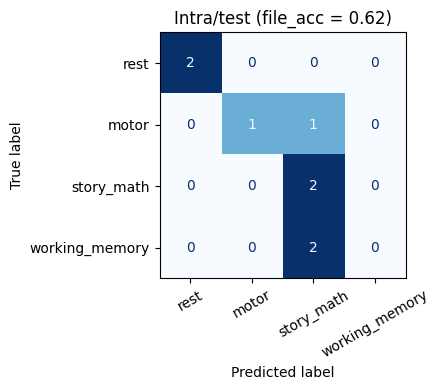

In [31]:
# Intra confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(intra_metrics["file_confusion_matrix"]),
    display_labels=[n.replace("task_", "") for n in CLASS_NAMES],
)
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=30, colorbar=False)
ax.set_title(f"Intra/test (file_acc = {intra_metrics['file_acc']:.2f})")
plt.tight_layout(); plt.show()


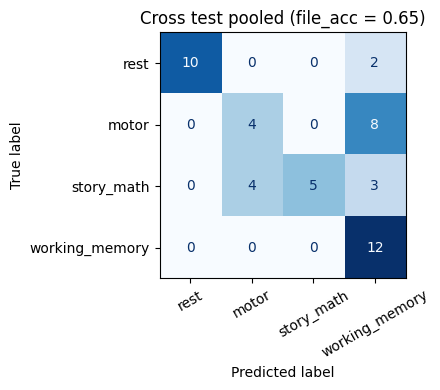

In [32]:
# Cross: pooled confusion matrix across test1/2/3 (file level)
pooled_true = np.concatenate([m["file_y_true"] for m in cross_test_metrics.values()])
pooled_pred = np.concatenate([m["file_y_pred"] for m in cross_test_metrics.values()])
cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(pooled_true, pooled_pred):
    cm[int(t), int(p)] += 1

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[n.replace("task_", "") for n in CLASS_NAMES],
)
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=30, colorbar=False)
ax.set_title(f"Cross test pooled (file_acc = {(pooled_true == pooled_pred).mean():.2f})")
plt.tight_layout(); plt.show()


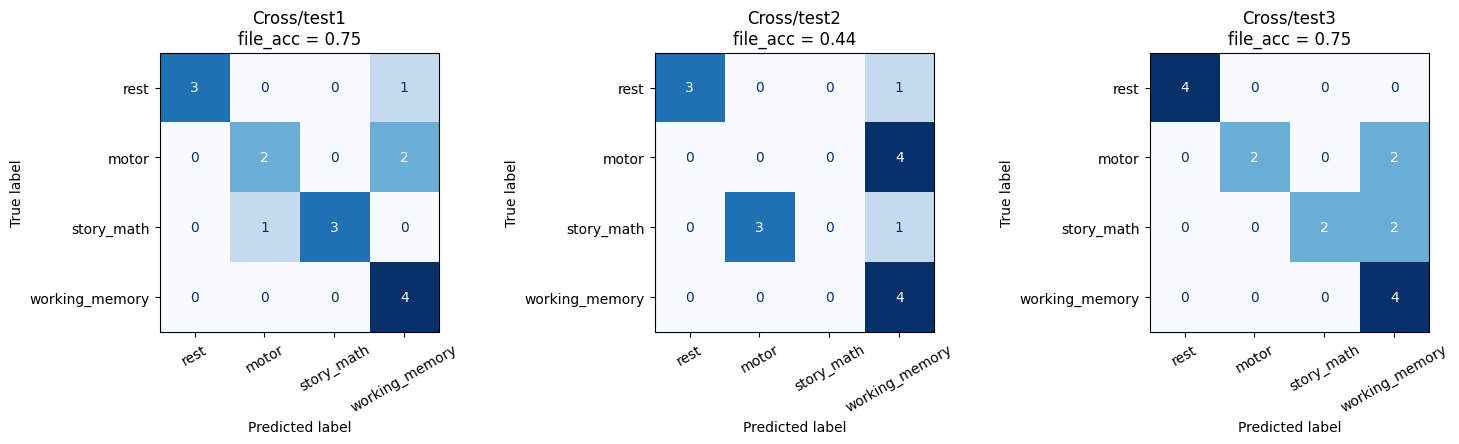

In [33]:
# Per-test-set confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, m) in zip(axes, cross_test_metrics.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=np.asarray(m["file_confusion_matrix"]),
        display_labels=[n.replace("task_", "") for n in CLASS_NAMES],
    )
    disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=30, colorbar=False)
    ax.set_title(f"{name}\nfile_acc = {m['file_acc']:.2f}")
plt.tight_layout(); plt.show()

In [ ]:
# Final summary table
print("=" * 72)
print("FINAL RESULTS SUMMARY")
print("=" * 72)
print()
print(f"Selected intra candidate:  {best_intra['candidate'].name}")
print(f"  best_epoch (val):        {best_intra['best_epoch']}")
print(f"  validation file_acc:     {best_intra['file_acc']:.3f}")
print(f"  Intra/test file_acc:     {intra_metrics['file_acc']:.3f}")
print(f"  Intra/test window_acc:   {intra_metrics['window_acc']:.3f}")
print()
print(f"Selected cross candidate:  {best_cross['candidate'].name}")
print(f"  LOSO mean file_acc:      {best_cross['mean_file_acc']:.3f}")
print(f"  final_epochs:            {best_cross['final_epochs']}")
for name, m in cross_test_metrics.items():
    print(f"  {name} file_acc: {m['file_acc']:.3f}  window_acc: {m['window_acc']:.3f}")
print(f"  Cross mean file_acc:     {mean_file:.3f}")
print(f"  Cross mean window_acc:   {mean_window:.3f}")


FINAL RESULTS SUMMARY

Selected intra candidate:  stronger_regularisation
  best_epoch (val):        20
  validation file_acc:     0.667
  Intra/test file_acc:     0.625
  Intra/test window_acc:   0.553

Selected cross candidate:  baseline_paper_scaled
  LOSO mean file_acc:      0.656
  final_epochs:            10
  Cross/test1 file_acc: 0.750  window_acc: 0.545
  Cross/test2 file_acc: 0.438  window_acc: 0.434
  Cross/test3 file_acc: 0.750  window_acc: 0.557
  Cross mean file_acc:     0.646
  Cross mean window_acc:   0.512


: 